# Semantic Image Segmentation with U-Net and MobileNetV2

This notebook implements **semantic image segmentation** on the Oxford-IIIT Pet dataset using a modified U-Net architecture. A pretrained MobileNetV2 network serves as the encoder, while a decoder with upsampling blocks and skip connections reconstructs a pixel-level segmentation mask.

The notebook covers the complete segmentation workflow:

- downloading the Oxford-IIIT Pet images and segmentation annotations directly from the official Oxford source
- image and mask preprocessing
- synchronized image-mask augmentation
- efficient `tf.data` pipelines
- transfer learning with a pretrained MobileNetV2 encoder
- U-Net-style skip connections and upsampling
- multiclass pixel-wise prediction
- training and validation monitoring
- qualitative mask visualization
- class-imbalance handling with per-pixel sample weights

The segmentation masks contain three pixel classes:

1. pet
2. pet border
3. surrounding/background region

> **Source attribution:** This implementation is based on the TensorFlow image segmentation tutorial and retains the original Apache 2.0 license notice.

## License and Attribution

Copyright 2019 The TensorFlow Authors.

Licensed under the Apache License, Version 2.0. The original tutorial is available from TensorFlow under the same license.


In [1]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


## 1. Environment Setup

This notebook uses TensorFlow and standard Python libraries. The Oxford-IIIT Pet images and segmentation annotations are downloaded directly from the official Oxford Visual Geometry Group dataset source.

The decoder upsampling blocks are implemented directly in the notebook, keeping the segmentation workflow self-contained.


In [2]:
from pathlib import Path

import tensorflow as tf
from IPython.display import clear_output
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Dataset: Oxford-IIIT Pet

The Oxford-IIIT Pet dataset contains images from 37 pet breeds together with pixel-level trimap segmentation masks.

This notebook downloads the official `images.tar.gz` and `annotations.tar.gz` archives directly from Oxford. The provided `trainval.txt` and `test.txt` files are used to preserve the dataset's standard training and test partitions.

Each trimap mask uses labels `{1, 2, 3}`. During preprocessing, these labels are shifted to `{0, 1, 2}` for sparse multiclass segmentation.


In [3]:
IMAGE_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
ANNOTATION_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

image_archive = Path(
    tf.keras.utils.get_file(
        fname="oxford_pet_images.tar.gz",
        origin=IMAGE_URL,
        extract=True,
        archive_format="tar",
    )
)

annotation_archive = Path(
    tf.keras.utils.get_file(
        fname="oxford_pet_annotations.tar.gz",
        origin=ANNOTATION_URL,
        extract=True,
        archive_format="tar",
    )
)

CACHE_DIR = annotation_archive.parent

# Keras versions can place extracted archives in slightly different
# subdirectories. Locate the official Oxford folders instead of assuming
# a fixed extraction path.
image_dirs = [
    path for path in CACHE_DIR.rglob("images")
    if path.is_dir() and any(path.glob("*.jpg"))
]

annotation_dirs = [
    path.parent for path in CACHE_DIR.rglob("trainval.txt")
    if path.name == "trainval.txt"
]

if not image_dirs:
    raise FileNotFoundError(
        f"Could not locate the extracted Oxford-IIIT Pet image directory under {CACHE_DIR}."
    )

if not annotation_dirs:
    raise FileNotFoundError(
        f"Could not locate trainval.txt under {CACHE_DIR}. "
        "Delete the cached Oxford Pet archives and rerun this cell if extraction was interrupted."
    )

IMAGE_DIR = image_dirs[0]
ANNOTATION_DIR = annotation_dirs[0]
MASK_DIR = ANNOTATION_DIR / "trimaps"

print("Image directory:", IMAGE_DIR)
print("Annotation directory:", ANNOTATION_DIR)
print("Mask directory:", MASK_DIR)
print("trainval.txt exists:", (ANNOTATION_DIR / "trainval.txt").exists())
print("test.txt exists:", (ANNOTATION_DIR / "test.txt").exists())
print("Number of image files:", len(list(IMAGE_DIR.glob("*.jpg"))))
print("Number of mask files:", len(list(MASK_DIR.glob("*.png"))))


791918971/791918971 ━━━━━━━━━━━━━━━━━━━━ 37s 0us/step
19173078/19173078 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Image directory: /root/.keras/datasets/oxford_pet_images_extracted/images
Annotation directory: /root/.keras/datasets/oxford_pet_annotations_extracted/annotations
Mask directory: /root/.keras/datasets/oxford_pet_annotations_extracted/annotations/trimaps
trainval.txt exists: True
test.txt exists: True
Number of image files: 7390
Number of mask files: 14780


## 3. Image and Mask Preprocessing

Images and masks are resized to `128 × 128`. Image pixels are normalized to `[0, 1]`, while segmentation-mask labels are shifted from `{1, 2, 3}` to `{0, 1, 2}`.

Nearest-neighbor interpolation is used for masks so resizing does not create invalid intermediate class values.


In [4]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.int32) - 1

    return input_image, input_mask


In [5]:
def load_image(image_path, mask_path):
    input_image = tf.io.read_file(image_path)
    input_image = tf.io.decode_jpeg(input_image, channels=3)

    input_mask = tf.io.read_file(mask_path)
    input_mask = tf.io.decode_png(input_mask, channels=1)

    input_image = tf.image.resize(
        input_image,
        (128, 128),
        method="bilinear"
    )

    input_mask = tf.image.resize(
        input_mask,
        (128, 128),
        method="nearest"
    )

    input_image, input_mask = normalize(
        input_image,
        input_mask
    )

    return input_image, input_mask


## 4. Training and Test Splits

The official Oxford `trainval.txt` and `test.txt` annotation files define the training and test partitions. These standard splits are retained.


In [6]:
def read_split_ids(split_file):
    split_file = Path(split_file)

    if not split_file.exists():
        raise FileNotFoundError(f"Split file not found: {split_file}")

    lines = split_file.read_text().strip().splitlines()
    return [line.split()[0] for line in lines if line.strip()]


train_ids = read_split_ids(ANNOTATION_DIR / "trainval.txt")
test_ids = read_split_ids(ANNOTATION_DIR / "test.txt")

train_image_paths = [
    str(IMAGE_DIR / f"{image_id}.jpg")
    for image_id in train_ids
]

train_mask_paths = [
    str(MASK_DIR / f"{image_id}.png")
    for image_id in train_ids
]

test_image_paths = [
    str(IMAGE_DIR / f"{image_id}.jpg")
    for image_id in test_ids
]

test_mask_paths = [
    str(MASK_DIR / f"{image_id}.png")
    for image_id in test_ids
]

TRAIN_LENGTH = len(train_image_paths)
TEST_LENGTH = len(test_image_paths)

BATCH_SIZE = 64
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

print("Training samples:", TRAIN_LENGTH)
print("Test samples:", TEST_LENGTH)
print("Batch size:", BATCH_SIZE)
print("Steps per epoch:", STEPS_PER_EPOCH)


Training samples: 3680
Test samples: 3669
Batch size: 64
Steps per epoch: 57


In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, train_mask_paths)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_image_paths, test_mask_paths)
)

train_images = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_images = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Training element specification:")
print(train_images.element_spec)


Training element specification:
(TensorSpec(shape=(128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(128, 128, 1), dtype=tf.int32, name=None))


## 5. Synchronized Image-Mask Augmentation

For segmentation, any spatial transformation applied to an image must also be applied to its mask. The custom augmentation layer uses the same random seed for both branches so the image and segmentation mask remain spatially aligned.


In [8]:
class Augment(tf.keras.layers.Layer):

    def __init__(self, seed=42):
        super().__init__()

        self.augment_inputs = tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=seed
        )

        self.augment_labels = tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=seed
        )

    def call(self, inputs, labels):
        inputs = self.augment_inputs(inputs)
        labels = self.augment_labels(labels)

        return inputs, labels


## 6. Efficient `tf.data` Input Pipeline

The training pipeline caches, shuffles, batches, repeats, augments, and prefetches the data. Augmentation is applied after batching so both the input images and masks are transformed consistently.


In [9]:
train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

test_batches = test_images.batch(BATCH_SIZE)


## 7. Visualize Images and Ground-Truth Masks

The helper below displays an input image, its true mask, and later the predicted segmentation mask.


In [10]:
def display(display_list):

    plt.figure(figsize=(15, 15))

    titles = [
        "Input Image",
        "True Mask",
        "Predicted Mask"
    ]

    for i in range(len(display_list)):
        plt.subplot(
            1,
            len(display_list),
            i + 1
        )

        plt.title(titles[i])

        plt.imshow(
            tf.keras.utils.array_to_img(
                display_list[i]
            )
        )

        plt.axis("off")

    plt.show()


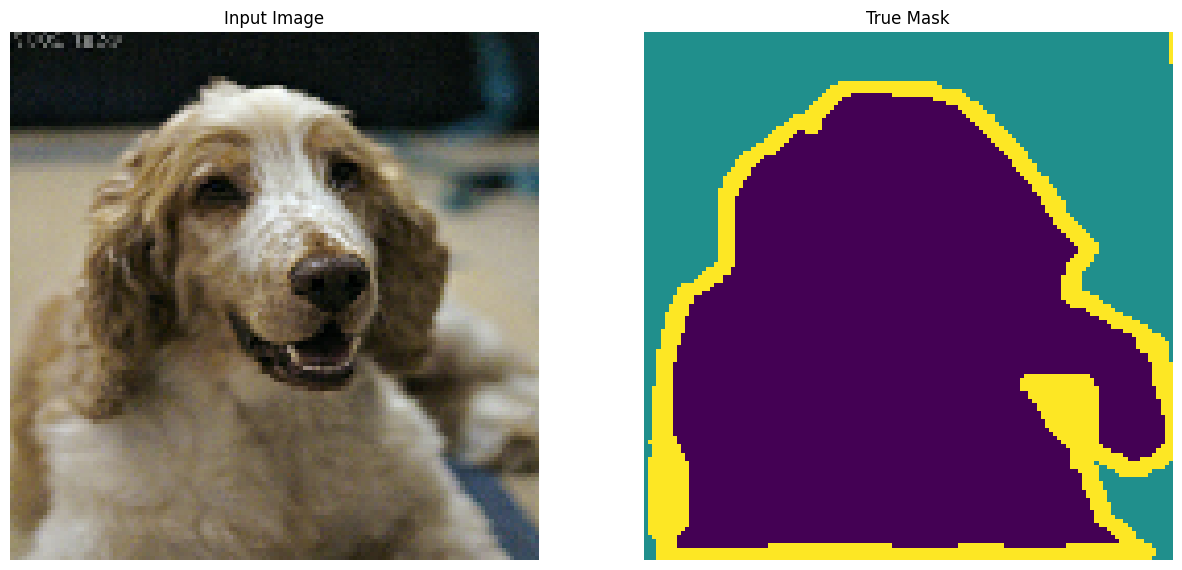

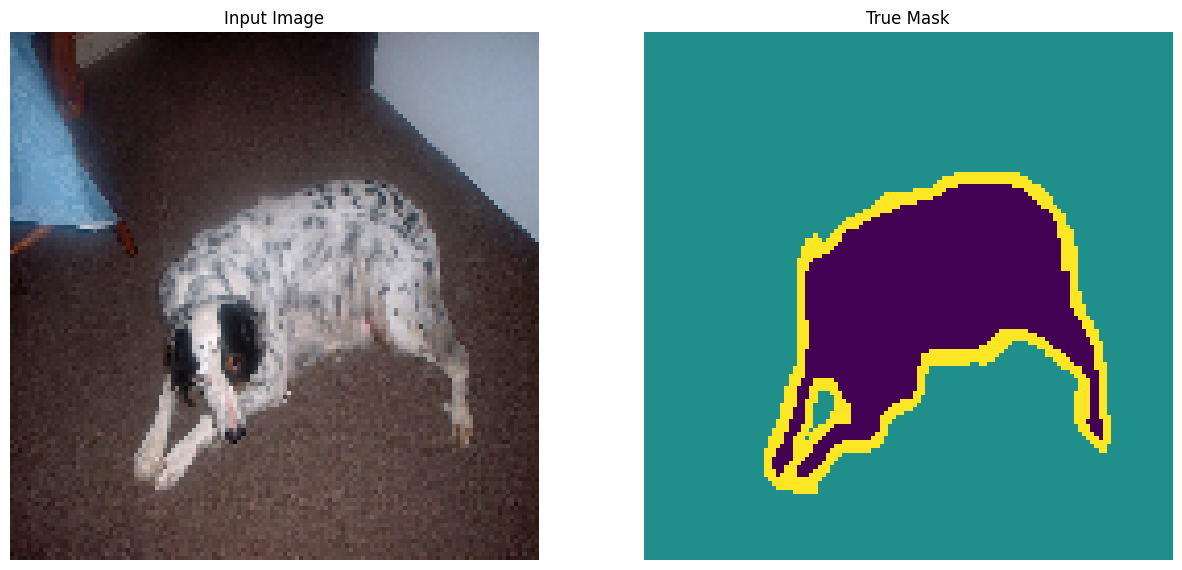

In [11]:
for images, masks in train_batches.take(2):
    sample_image = images[0]
    sample_mask = masks[0]

    display([
        sample_image,
        sample_mask
    ])


## 8. Modified U-Net Architecture

U-Net combines a **downsampling encoder** and an **upsampling decoder**. Skip connections transfer intermediate encoder features directly to the decoder, helping recover spatial details needed for pixel-level prediction.

### Encoder: MobileNetV2

A pretrained MobileNetV2 model is used as the feature extractor. Intermediate activation maps are collected at progressively smaller spatial resolutions. The encoder is frozen during training.


In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=[128, 128, 3],
    include_top=False
)

layer_names = [
    "block_1_expand_relu",   # 64 x 64
    "block_3_expand_relu",   # 32 x 32
    "block_6_expand_relu",   # 16 x 16
    "block_13_expand_relu",  # 8 x 8
    "block_16_project",      # 4 x 4
]

base_model_outputs = [
    base_model.get_layer(name).output
    for name in layer_names
]

down_stack = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model_outputs
)

down_stack.trainable = False

down_stack.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 1,841,984 (7.03 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,841,984 (7.03 MB)

## Decoder: Upsampling Blocks

The decoder progressively restores spatial resolution using transposed convolutions, batch normalization, and ReLU activation. Skip connections from the MobileNetV2 encoder preserve higher-resolution spatial information.


In [13]:
def upsample(filters, size):
    """Create one decoder upsampling block for the modified U-Net."""
    initializer = tf.random_normal_initializer(0.0, 0.02)

    return tf.keras.Sequential([
        tf.keras.layers.Conv2DTranspose(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False,
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
    ])


### Assemble the U-Net

Each decoder block is concatenated with the corresponding encoder feature map. The final transposed convolution restores the output to `128 × 128` with one channel of logits per segmentation class.


In [14]:
def unet_model(output_channels: int):

    inputs = tf.keras.layers.Input(
        shape=[128, 128, 3]
    )

    # Frozen MobileNetV2 encoder feature maps
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Create a fresh decoder for every new U-Net model.
    up_stack = [
        upsample(512, 3),  # 4x4 -> 8x8
        upsample(256, 3),  # 8x8 -> 16x16
        upsample(128, 3),  # 16x16 -> 32x32
        upsample(64, 3),   # 32x32 -> 64x64
    ]

    # Decoder and skip connections
    for up, skip in zip(
        up_stack,
        skips
    ):
        x = up(x)
        x = tf.keras.layers.Concatenate()(
            [x, skip]
        )

    # Final segmentation logits
    last = tf.keras.layers.Conv2DTranspose(
        filters=output_channels,
        kernel_size=3,
        strides=2,
        padding="same"
    )

    x = last(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=x
    )


## 9. Compile the Segmentation Model

This is a **multiclass pixel-classification problem** with integer mask labels, so the model uses `SparseCategoricalCrossentropy(from_logits=True)`.

For every pixel, the predicted class is the output channel with the highest logit.


In [15]:
OUTPUT_CLASSES = 3

model = unet_model(
    output_channels=OUTPUT_CLASSES
)

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 8, 8, 512) │  1,476,608 │ functional[0][4]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ sequential[0][0], │
│ (Concatenate)       │ 1088)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 16, 16,    │  2,507,776 │ concatenate[0][0] │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 448)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    516,608 │ concatenate_1[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ sequential_2[0][… │
│ (Concatenate)       │ 272)              │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 64,    │    156,928 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64,    │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 160)              │            │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │      4,323 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,504,227 (24.81 MB)

 Trainable params: 4,660,323 (17.78 MB)

 Non-trainable params: 1,843,904 (7.03 MB)

### Visualize the Model Architecture


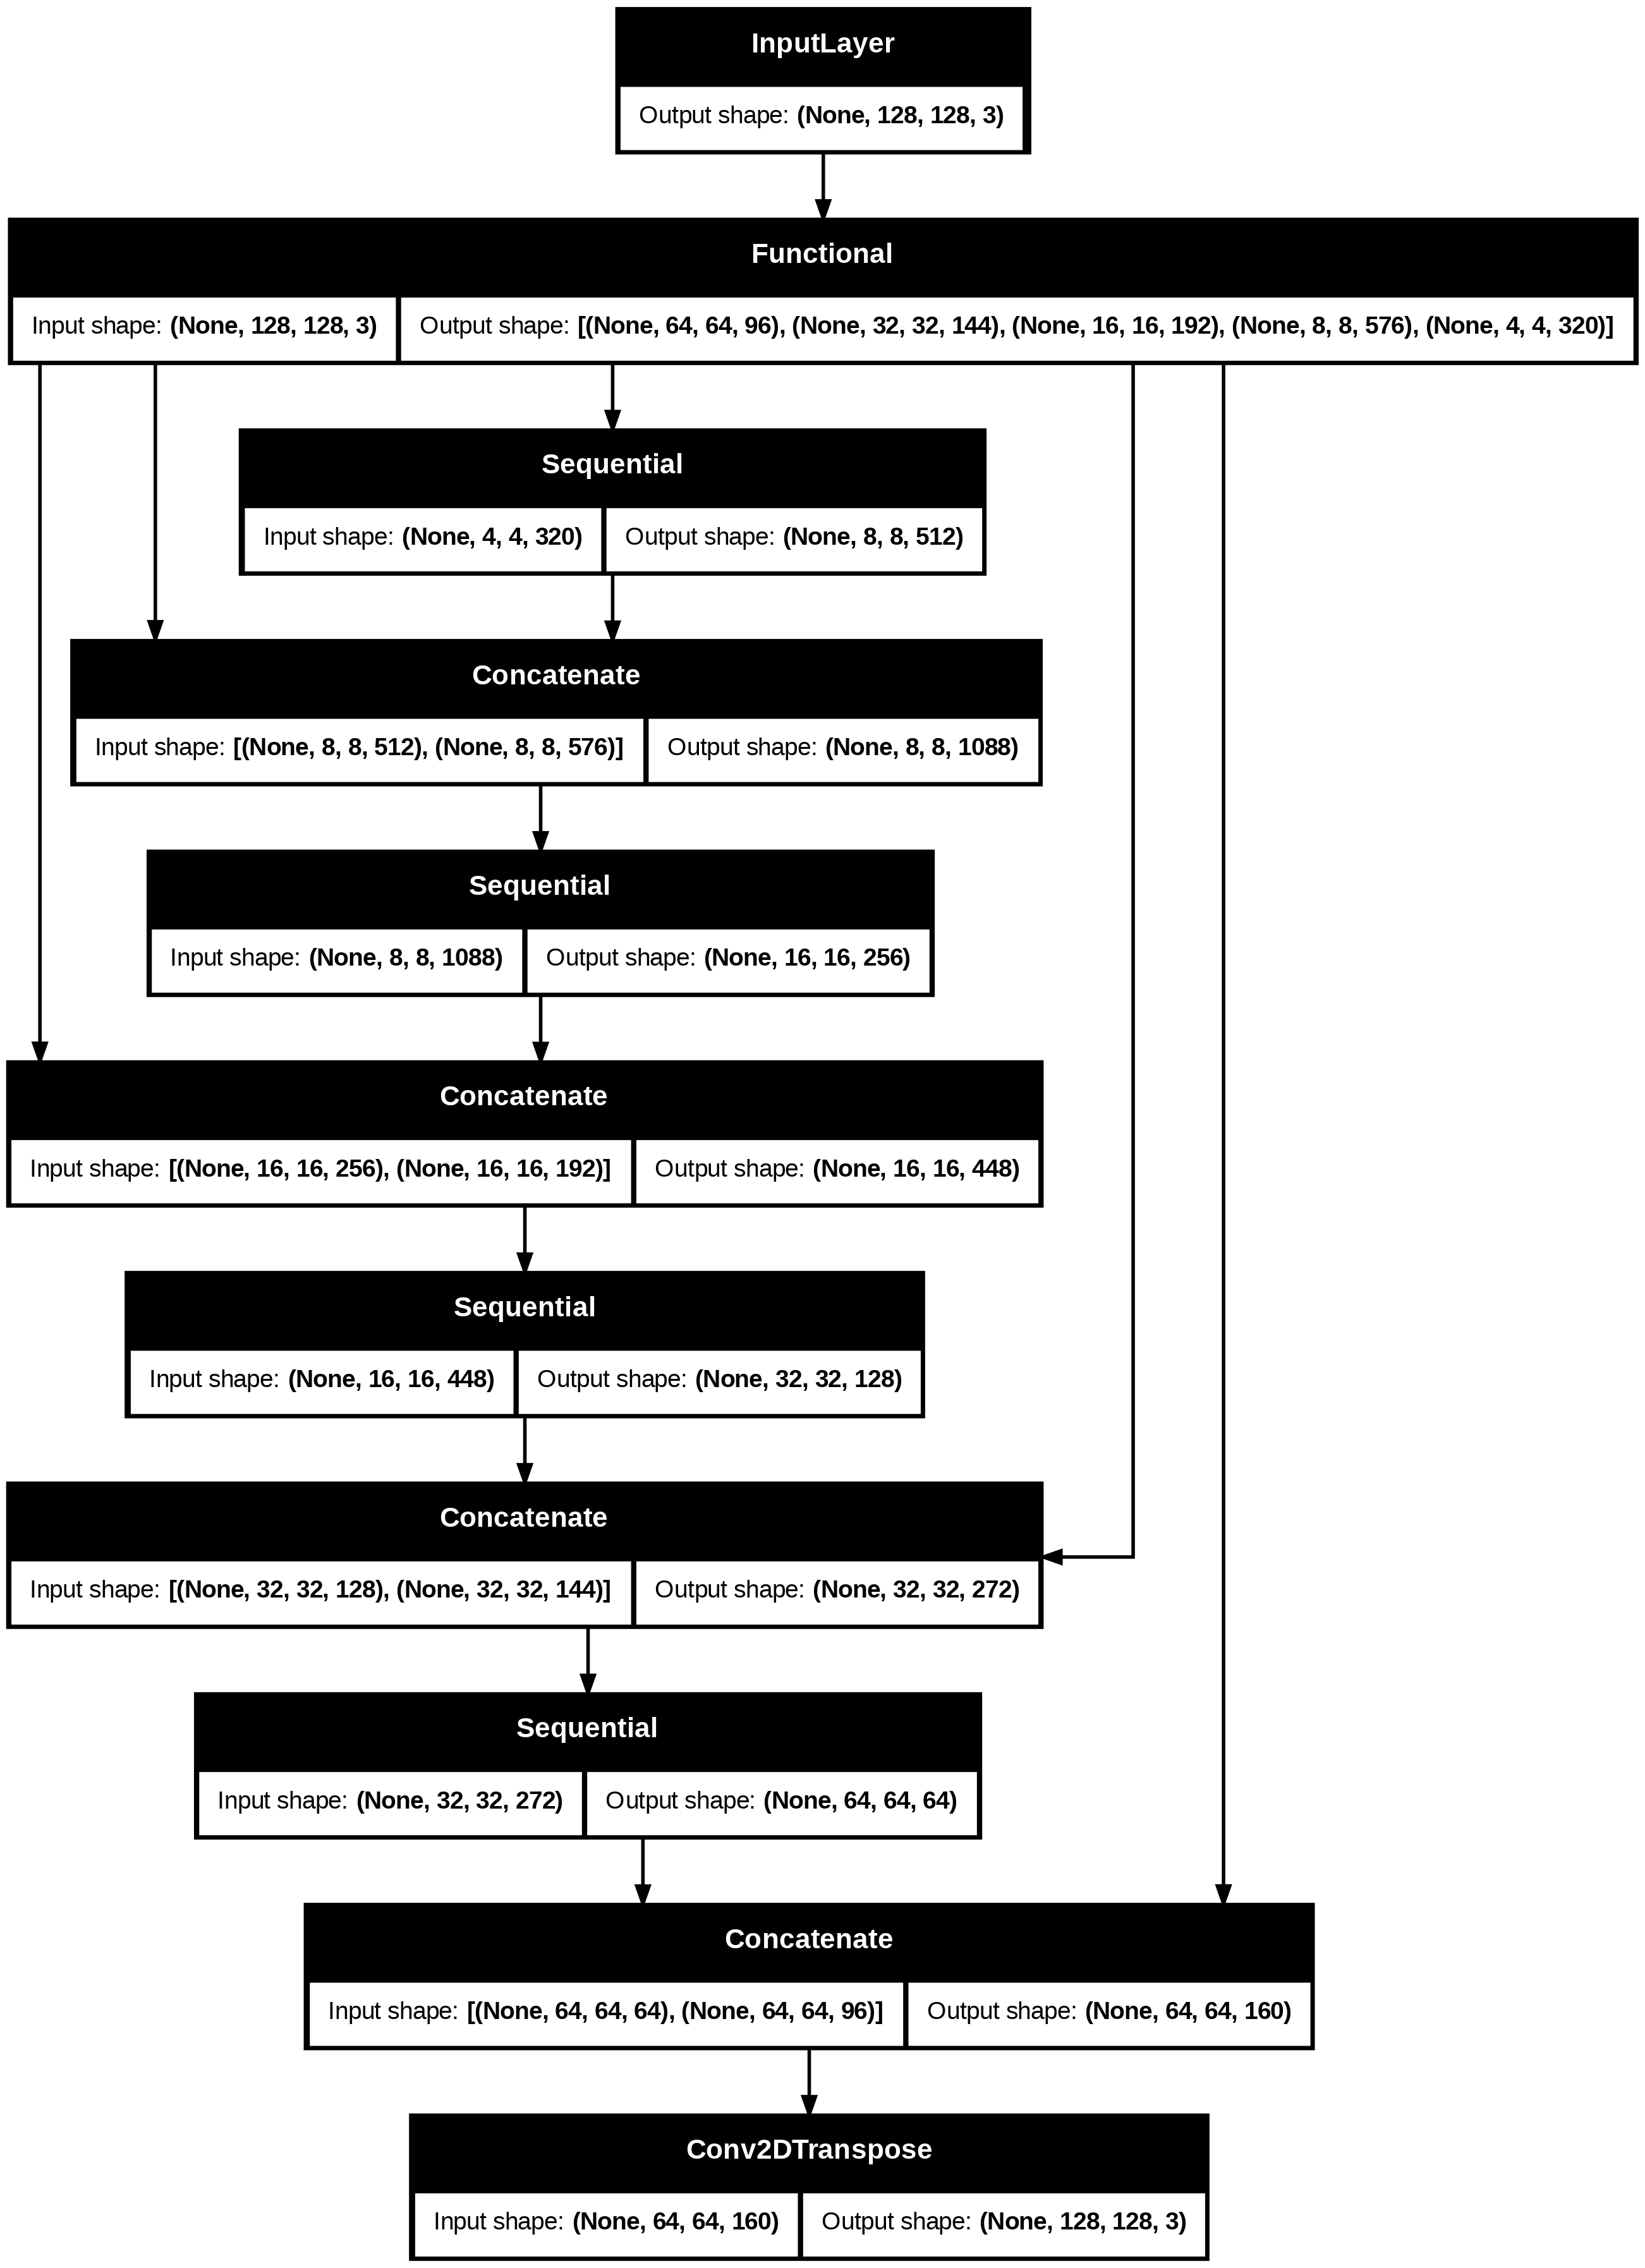

In [16]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True
)


## 10. Prediction Helpers

`create_mask` converts the model's per-pixel logits into a single integer class for each pixel.


In [17]:
def create_mask(pred_mask):

    pred_mask = tf.math.argmax(
        pred_mask,
        axis=-1
    )

    pred_mask = pred_mask[
        ...,
        tf.newaxis
    ]

    return pred_mask[0]


In [18]:
def show_predictions(
    dataset=None,
    num=1
):

    if dataset is not None:

        for image, mask in dataset.take(num):

            pred_mask = model.predict(
                image,
                verbose=0
            )

            display([
                image[0],
                mask[0],
                create_mask(pred_mask)
            ])

    else:

        pred_mask = model.predict(
            sample_image[
                tf.newaxis,
                ...
            ],
            verbose=0
        )

        display([
            sample_image,
            sample_mask,
            create_mask(pred_mask)
        ])


### Prediction Before Training

Running the model before training provides a useful baseline for comparison with later predictions.


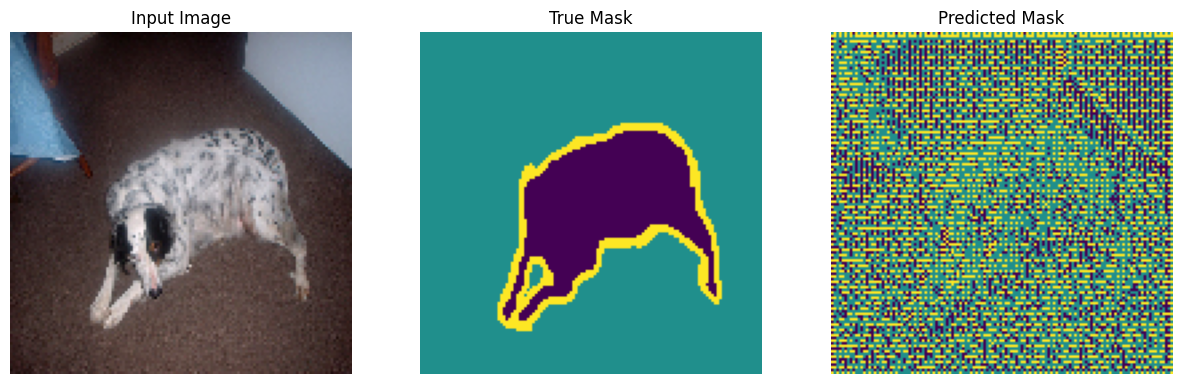

In [19]:
show_predictions()


## 11. Monitor Segmentation During Training

The callback displays a sample prediction after every epoch so the qualitative development of the segmentation mask can be observed alongside numerical training metrics.


In [20]:
class DisplayCallback(
    tf.keras.callbacks.Callback
):

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        clear_output(wait=True)

        show_predictions()

        print(
            "\nSample prediction after epoch {}\n".format(
                epoch + 1
            )
        )


## 12. Train the U-Net


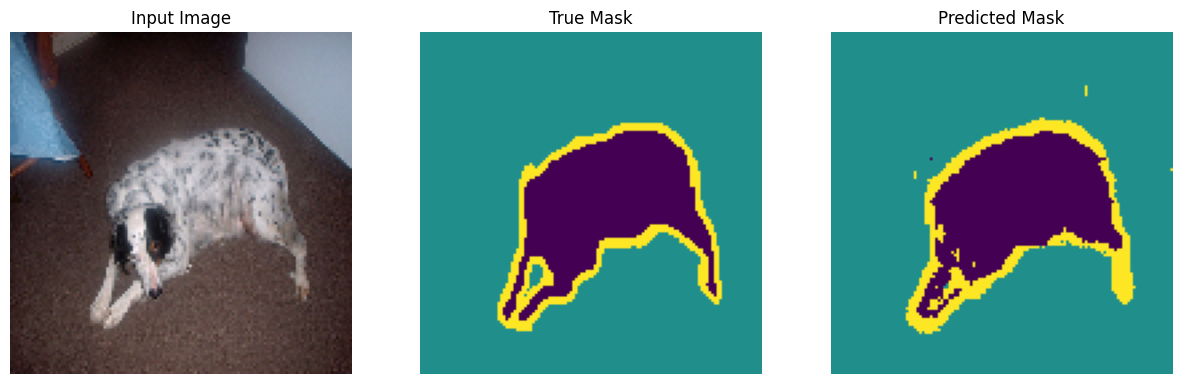


Sample prediction after epoch 20

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9285 - loss: 0.1757 - val_accuracy: 0.9008 - val_loss: 0.2649


In [21]:
EPOCHS = 20
VAL_SUBSPLITS = 5

VALIDATION_STEPS = (
    TEST_LENGTH
    // BATCH_SIZE
    // VAL_SUBSPLITS
)

model_history = model.fit(
    train_batches,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=test_batches,
    callbacks=[DisplayCallback()]
)


## 13. Training vs Validation Loss


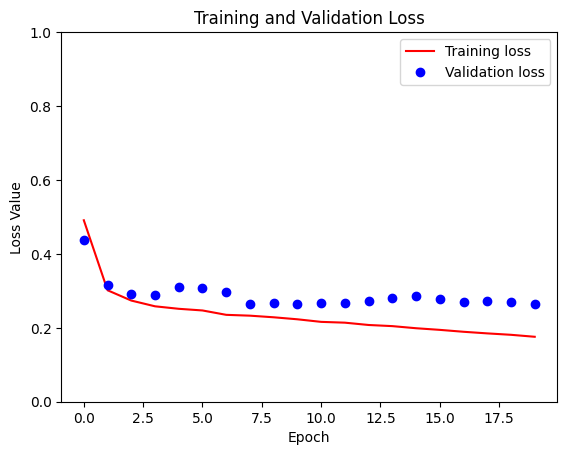

In [22]:
loss = model_history.history["loss"]
val_loss = model_history.history["val_loss"]

plt.figure()

plt.plot(
    model_history.epoch,
    loss,
    "r",
    label="Training loss"
)

plt.plot(
    model_history.epoch,
    val_loss,
    "bo",
    label="Validation loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss Value")

plt.ylim([0, 1])

plt.legend()

plt.show()


## 14. Evaluate Segmentation Predictions

The following examples compare each input image with its ground-truth mask and the model's predicted mask.


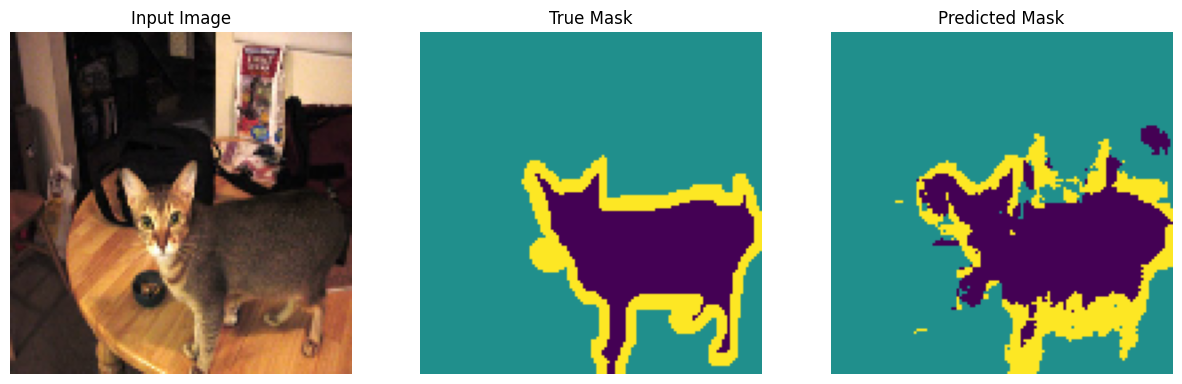

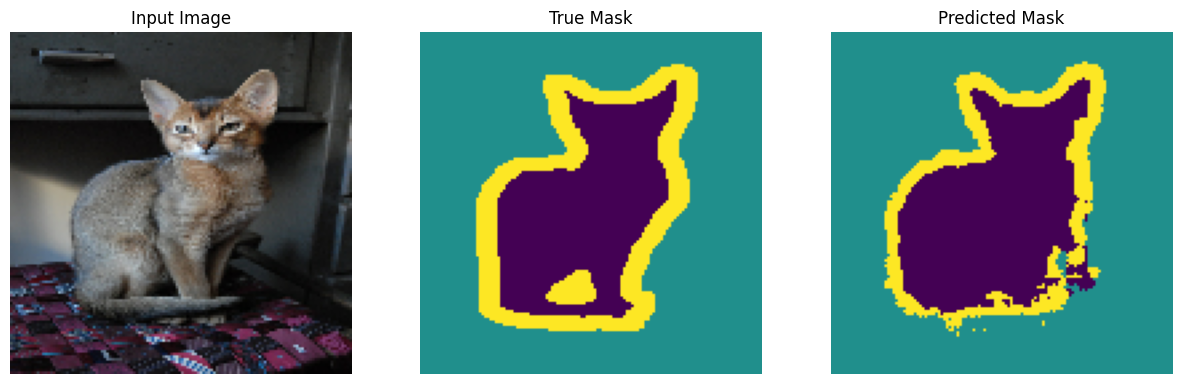

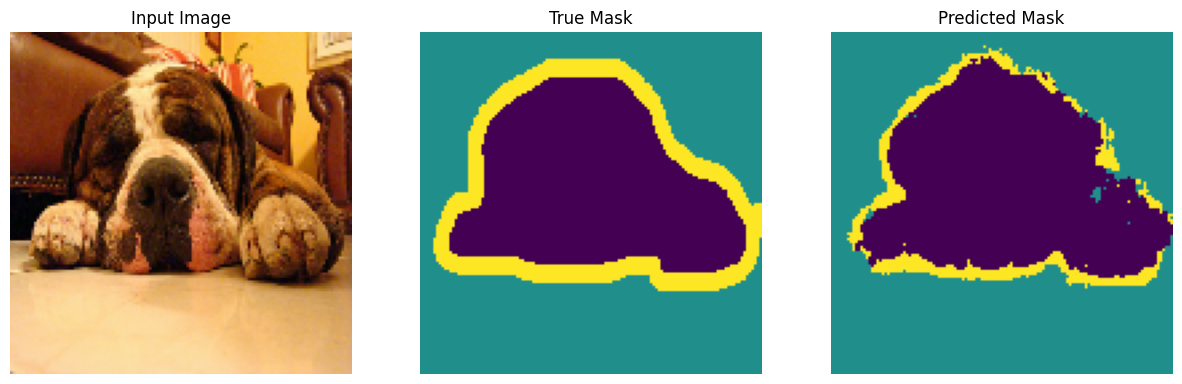

In [23]:
show_predictions(
    test_batches,
    3
)


## 15. Class Imbalance in Semantic Segmentation

Semantic-segmentation datasets can be imbalanced because some pixel classes occupy much larger areas than others.

For dense segmentation targets, sample-level `class_weight` is not the appropriate mechanism for assigning different importance to individual pixels. The following section therefore constructs a **per-pixel sample-weight map**, which can be passed to Keras as `(image, mask, sample_weight)` triples.


In [24]:
print("Example segmentation mask shape:", sample_mask.shape)
print(
    "For pixel-level imbalance, this notebook uses a sample-weight map "
    "instead of sample-level class_weight."
)


Example segmentation mask shape: (128, 128, 1)
For pixel-level imbalance, this notebook uses a sample-weight map instead of sample-level class_weight.


## 16. Per-Pixel Sample Weight Demonstration

Instead of `class_weight`, Keras can receive `(data, label, sample_weight)` triples. The sample weight is multiplied into the unreduced loss before reduction.

This small example demonstrates how different weights affect otherwise identical predictions.


In [25]:
label = tf.constant([0, 0])

prediction = tf.constant(
    [
        [-3.0, 0.0],
        [-3.0, 0.0]
    ]
)

sample_weight = tf.constant(
    [
        1.0,
        10.0
    ]
) # Use float type for sample_weight

loss_example = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction=tf.keras.losses.Reduction.NONE
)

weighted_loss_example = loss_example(
    label,
    prediction,
    sample_weight
).numpy()

print(
    "Weighted loss example:",
    weighted_loss_example
)

Weighted loss example: [ 3.0485873 30.485874 ]


## 17. Build Per-Pixel Class Weights

The segmentation label at every pixel is used as an index into a class-weight vector. The result is a one-channel sample-weight image aligned with the segmentation mask.


In [26]:
def add_sample_weights(
    image,
    label
):

    class_weights = tf.constant([
        2.0,
        2.0,
        1.0
    ])

    class_weights = (
        class_weights
        / tf.reduce_sum(class_weights)
    )

    sample_weights = tf.gather(
        class_weights,
        indices=tf.cast(
            label,
            tf.int32
        )
    )

    return (
        image,
        label,
        sample_weights
    )


### Inspect the Weighted Dataset Structure


In [27]:
train_batches.map(
    add_sample_weights
).element_spec


(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None))

## 18. Train with Per-Pixel Sample Weights

A second U-Net is created with a fresh decoder and trained briefly using the weighted dataset. This is intentionally a **pipeline demonstration**, not a performance comparison with the fully trained baseline model.

The short run verifies that Keras can consume per-pixel sample weights for semantic segmentation without repeating the full training and visualization workflow shown above.


In [28]:
weighted_model = unet_model(
    OUTPUT_CLASSES
)

weighted_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)


In [29]:
weighted_history = weighted_model.fit(
    train_batches.map(
        add_sample_weights
    ),
    epochs=1,
    steps_per_epoch=10
)


10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5950 - loss: 0.3171


## Standard vs Pixel-Weighted Training

The baseline U-Net is the fully trained segmentation model in this notebook. The weighted model is included only to demonstrate how pixel-level weighting can be incorporated when class imbalance is a concern.

Because the weighted model is trained for only a small number of steps, its output should **not** be interpreted as a fair performance comparison with the baseline. A rigorous comparison would train both models under the same schedule and evaluate segmentation-specific metrics such as mean IoU or Dice score.


## 19. Segmentation Takeaways

This project demonstrates an end-to-end semantic-segmentation pipeline using transfer learning:

- **MobileNetV2** extracts multiscale visual features.
- **U-Net skip connections** preserve spatial detail during reconstruction.
- **Transposed convolutions** restore image resolution for pixel-wise prediction.
- **Synchronized augmentation** keeps images and masks aligned.
- **Sparse categorical cross-entropy** supports the three integer mask classes.
- **Per-pixel sample weighting** provides a practical way to address class imbalance when ordinary `class_weight` is not supported for segmentation masks.

Natural extensions include experimenting with different encoder backbones, changing the selected MobileNetV2 skip layers, evaluating additional segmentation metrics such as IoU or Dice score, and applying the pipeline to other image-masking datasets.
